# CustomerPulse - Exploratory Data Analysis

## Project Objective

The objective of this exploratory data analysis is to understand:

- Sales patterns
- Customer behavior
- Product performance
- Regional trends
- Delivery performance

using the cleaned Olist dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Load Cleaned Datasets

In [2]:
customers = pd.read_csv("../Data/Cleaned/olist_customers_dataset.csv")
geolocation = pd.read_csv("../Data/Cleaned/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../Data/Cleaned/olist_order_items_dataset.csv")
payments = pd.read_csv("../Data/Cleaned/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../Data/Cleaned/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../Data/Cleaned/olist_orders_dataset.csv")
products = pd.read_csv("../Data/Cleaned/olist_products_dataset.csv")
sellers = pd.read_csv("../Data/Cleaned/olist_sellers_dataset.csv")
category_translation = pd.read_csv("../Data/Cleaned/product_category_name_translation.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Dataset Overview

In [3]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

In [4]:
for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])


CUSTOMERS
Rows: 99441
Columns: 5

GEOLOCATION
Rows: 738332
Columns: 5

ORDER_ITEMS
Rows: 112650
Columns: 7

PAYMENTS
Rows: 103886
Columns: 5

REVIEWS
Rows: 99224
Columns: 7

ORDERS
Rows: 99441
Columns: 8

PRODUCTS
Rows: 32951
Columns: 9

SELLERS
Rows: 3095
Columns: 4

CATEGORY_TRANSLATION
Rows: 71
Columns: 2


# Revenue Analysis

In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
total_revenue = order_items["price"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 13,591,643.70


In [7]:
total_freight = order_items["freight_value"].sum()

print(f"Total Freight Cost: {total_freight:,.2f}")

Total Freight Cost: 2,251,909.54


# Monthly Revenue Trend Analysis

In [8]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [9]:
orders["order_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [10]:
sales_data = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

Calculate Monthly Revenue

In [11]:
monthly_revenue = (
    sales_data
    .groupby("order_month")["price"]
    .sum()
    .reset_index()
)

In [12]:
monthly_revenue.head()

,order_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


In [13]:
monthly_revenue["order_month"] = (
    monthly_revenue["order_month"]
    .astype(str)
)

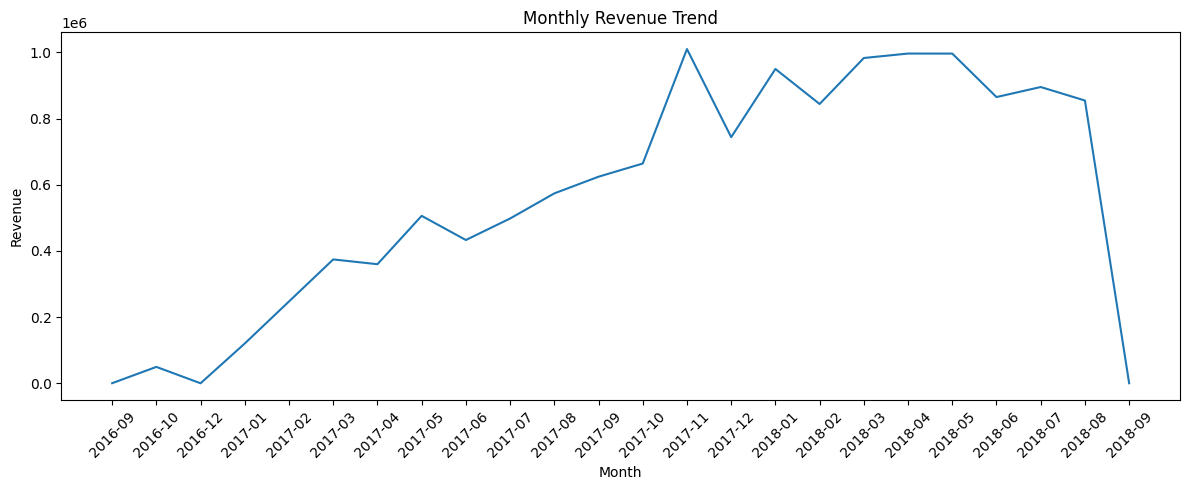

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["price"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Revenue Trend Insights

Highest Revenue month

In [15]:
monthly_revenue.sort_values(
    by="price",
    ascending=False
).head(1)

,order_month,price
13,2017-11,1010271.37


Lowest Revenue month

In [16]:
monthly_revenue.sort_values(
    by="price",
    ascending=True
).head(1)

,order_month,price
2,2016-12,10.9


Statistics

In [17]:
monthly_revenue["price"].describe()

count    2.400000e+01
mean     5.663185e+05
std      3.566705e+05
min      1.090000e+01
25%      3.317712e+05
50%      5.991867e+05
75%      8.727200e+05
max      1.010271e+06
Name: price, dtype: float64

# Product Category Revenue Analysis

In [18]:
products_en = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [19]:
products_en["product_category_name_english"] = (
    products_en["product_category_name_english"]
    .fillna("Unknown")
)

In [20]:
sales_products = order_items.merge(
    products_en,
    on="product_id",
    how="left"
)

In [21]:
category_revenue = (
    sales_products
    .groupby("product_category_name_english")["price"]
    .sum()
    .reset_index()
)

Top 10 categories

In [22]:
top_categories = (
    category_revenue
    .sort_values(
        by="price",
        ascending=False
    )
    .head(10)
)

top_categories

,product_category_name_english,price
44,health_beauty,1258681.34
71,watches_gifts,1205005.68
8,bed_bath_table,1036988.68
66,sports_leisure,988048.97
16,computers_accessories,911954.32
40,furniture_decor,729762.49
21,cool_stuff,635290.85
50,housewares,632248.66
6,auto,592720.11
43,garden_tools,485256.46


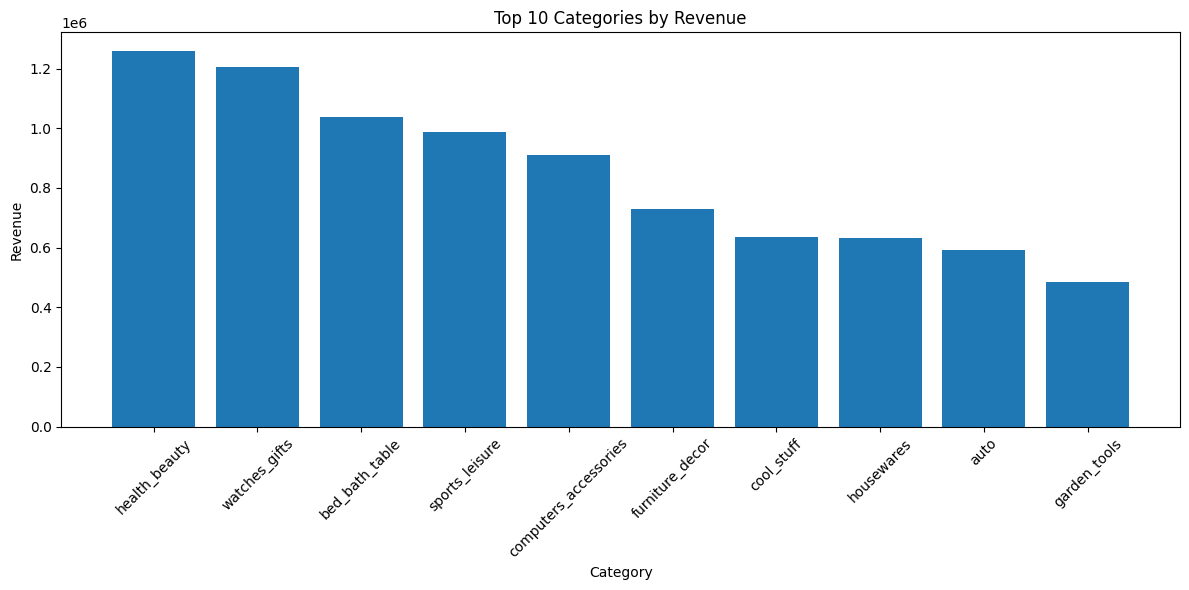

In [23]:
plt.figure(figsize=(12,6))

plt.bar(
    top_categories["product_category_name_english"],
    top_categories["price"]
)

plt.title("Top 10 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Customer Analysis

Total Unique Customers

In [24]:
total_customers = customers["customer_unique_id"].nunique()

print("Total Unique Customers:", total_customers)

Total Unique Customers: 96096


In [25]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="inner"
)

In [26]:
customer_frequency = (
    customer_orders
    .groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index()
)

customer_frequency.columns = [
    "customer_unique_id",
    "order_count"
]

Frequency Statistics

In [27]:
customer_frequency["order_count"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_count, dtype: float64

Repeat Customers

In [28]:
repeat_customers = customer_frequency[
    customer_frequency["order_count"] > 1
]

print(
    "Repeat Customers:",
    repeat_customers.shape[0]
)

Repeat Customers: 2997


Repeat Customer Rate

In [29]:
repeat_rate = (
    repeat_customers.shape[0]
    / customer_frequency.shape[0]
) * 100

print(
    f"Repeat Customer Rate: {repeat_rate:.2f}%"
)

Repeat Customer Rate: 3.12%


# Top Customers by Revenue

In [30]:
customer_sales = (
    sales_data
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
)

In [31]:
customer_revenue = (
    customer_sales
    .groupby("customer_unique_id")["price"]
    .sum()
    .reset_index()
)

Top 10 Customers

In [32]:
top_customers = (
    customer_revenue
    .sort_values(
        by="price",
        ascending=False
    )
    .head(10)
)

top_customers

,customer_unique_id,price
3799,0a0a92112bd4c708ca5fde585afaa872,13440.0
81388,da122df9eeddfedc1dc1f5349a1a690c,7388.0
44139,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
82230,dc4802a71eae9be1dd28f5d788ceb526,6735.0
26015,459bef486812aa25204be022145caa62,6729.0
95131,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
23947,4007669dec559734d6f53e029e360987,5934.6
89056,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
34820,5d0a2980b292d049061542014e8960bf,4599.9
27242,48e1ac109decbb87765a3eade6854098,4590.0


Top customer contribution

In [33]:
top_customer_revenue = (
    top_customers["price"]
    .sum()
)

contribution_pct = (
    top_customer_revenue
    / customer_revenue["price"].sum()
) * 100

print(
    f"Top 10 Customer Contribution: {contribution_pct:.2f}%"
)

Top 10 Customer Contribution: 0.50%


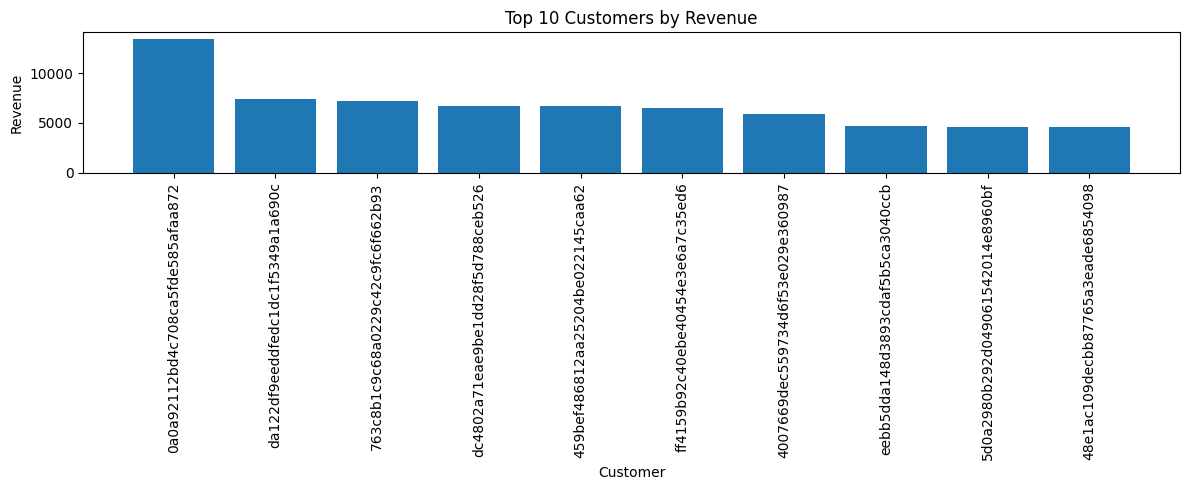

In [34]:
plt.figure(figsize=(12,5))

plt.bar(
    top_customers["customer_unique_id"],
    top_customers["price"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

# Regional Revenue Analysis

In [35]:
regional_sales = (
    sales_data
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
)

Revenue ny State calculation

In [36]:
state_revenue = (
    regional_sales
    .groupby("customer_state")["price"]
    .sum()
    .reset_index()
)

Top States

In [37]:
top_states = (
    state_revenue
    .sort_values(
        by="price",
        ascending=False
    )
    .head(10)
)

top_states

,customer_state,price
25,SP,5202955.05
18,RJ,1824092.67
10,MG,1585308.03
22,RS,750304.02
17,PR,683083.76
23,SC,520553.34
4,BA,511349.99
6,DF,302603.94
8,GO,294591.95
7,ES,275037.31


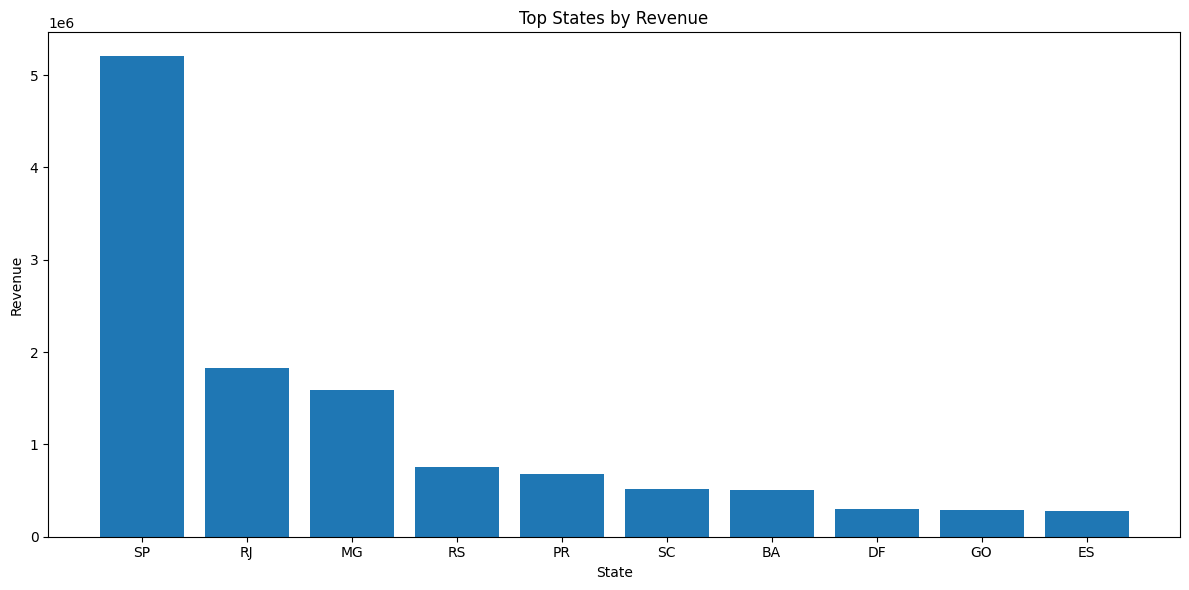

In [38]:
plt.figure(figsize=(12,6))

plt.bar(
    top_states["customer_state"],
    top_states["price"]
)

plt.title("Top States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

Revenue concentration

In [39]:
top5_state_pct = (
    top_states.head(5)["price"].sum()
    / state_revenue["price"].sum()
) * 100

print(
    f"Top 5 States Contribution: {top5_state_pct:.2f}%"
)

Top 5 States Contribution: 73.91%


# Delivery Performance Analysis

In [40]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

In [41]:
delivery_data = orders.copy()

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

Delivery Statistics

In [42]:
delivery_data["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

Average delivery time

In [43]:
avg_delivery_days = (
    delivery_data["delivery_days"]
    .mean()
)

print(
    f"Average Delivery Days: {avg_delivery_days:.2f}"
)

Average Delivery Days: 12.09


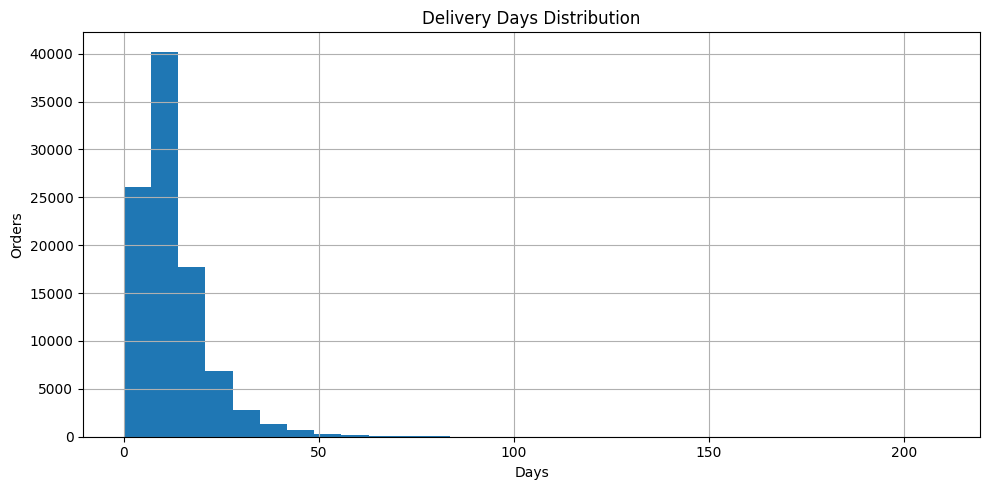

In [44]:
plt.figure(figsize=(10,5))

delivery_data["delivery_days"].hist(
    bins=30
)

plt.title("Delivery Days Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")

plt.tight_layout()

plt.show()